# Part 4 — Attention and Self-Attention

**Guiding question:** How does each query assign weights to available information and combine it?

**Purpose:** calculate one attention head step by step, visualize every matrix, apply a causal mask, and connect the arithmetic to self-attention.

**Runtime:** about 30 minutes. **Prerequisite:** vectors can represent tokens; matrix multiplication forms dot products. **Roadmap:** weighted average → Q/K/V → scores → softmax → weighted sum → mask → self-attention → positional encoding → PyTorch check.

**Convention:** heat-map rows are **queries** and columns are **keys**. In our masks, `True = allowed`. All tensors are fixed classroom examples—not learned clinical semantics. Run from top to bottom.

## 0. Setup

A **tensor** is a multidimensional numerical array. We use CPU and `float64` so the small values are reproducible and easy to inspect. [PyTorch tensor documentation](https://pytorch.org/docs/stable/tensors.html) describes the array operations used below.

In [1]:
import math, sys
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyBboxPatch

torch.manual_seed(42)
DTYPE = torch.float64
print({'python':sys.version.split()[0], 'torch':torch.__version__, 'device':'cpu', 'dtype':str(DTYPE)})

{'python': '3.13.5', 'torch': '2.12.0+cu130', 'device': 'cpu', 'dtype': 'torch.float64'}


## 1. Start with the destination: a weighted average

Attention ultimately computes a weighted combination of **value vectors**. If the weights are `0.75` and `0.25`, the output receives three times as much contribution from the first value as from the second. The weights must be non-negative and sum to one.

This simple calculation is not yet attention—the next sections explain how Q and K produce the weights.

In [2]:
demo_values = torch.tensor([[10.,0.], [0.,20.]], dtype=DTYPE)
demo_weights = torch.tensor([.75,.25], dtype=DTYPE)
demo_output = demo_weights @ demo_values
weighted_parts = demo_weights[:,None] * demo_values

display(pd.DataFrame(weighted_parts.numpy(), index=['0.75 × value 1','0.25 × value 2'], columns=['feature 1','feature 2']).round(2))
print('Add the rows → output:', demo_output.tolist())
assert torch.allclose(weighted_parts.sum(0), demo_output) and torch.isclose(demo_weights.sum(), torch.tensor(1.,dtype=DTYPE))

,feature 1,feature 2
0.75 × value 1,7.5,0.0
0.25 × value 2,0.0,5.0


Add the rows → output: [7.5, 5.0]


### What do we see?

The output is `[7.5, 5.0]`: attention does not select just one value; it can blend several. A larger weight means a larger numerical contribution **in this operation**, not human-like importance or a causal explanation.

## 2. The attention recipe and matrix shapes

For queries `Q`, keys `K`, and values `V`:

1. **Match:** `QKᵀ` compares every query with every key.
2. **Scale:** divide by `√d_k` to limit increasingly extreme dot products.
3. **Normalize:** row-wise softmax turns each score row into weights summing to one.
4. **Combine:** `weights @ V` makes one output vector per query.

`n_q` is the number of queries, `n_k` the number of keys, `d_k` the query/key width, and `d_v` the value width.

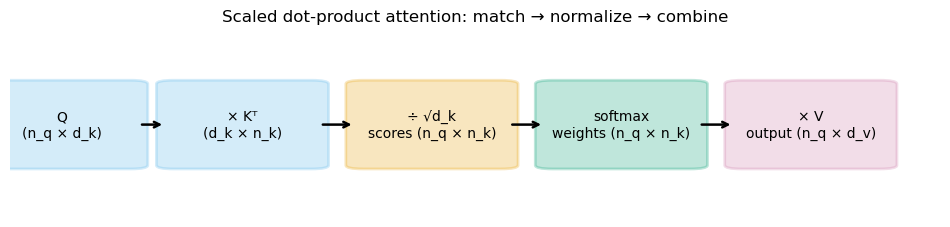

In [3]:
steps = [
 ('Q\n(n_q × d_k)', 0.06, '#56B4E9'), ('× Kᵀ\n(d_k × n_k)', 0.27, '#56B4E9'),
 ('÷ √d_k\nscores (n_q × n_k)', 0.49, '#E69F00'), ('softmax\nweights (n_q × n_k)', 0.71, '#009E73'),
 ('× V\noutput (n_q × d_v)', 0.93, '#CC79A7')]
fig, ax = plt.subplots(figsize=(12,2.4)); ax.set_xlim(0,1.08); ax.set_ylim(0,1); ax.axis('off')
for i,(label,x,color) in enumerate(steps):
    ax.add_patch(FancyBboxPatch((x-.08,.28),.16,.44,boxstyle='round,pad=.02',facecolor=color,alpha=.25,edgecolor=color,linewidth=2))
    ax.text(x,.5,label,ha='center',va='center',fontsize=10)
    if i < len(steps)-1: ax.annotate('',xy=(steps[i+1][1]-.09,.5),xytext=(x+.09,.5),arrowprops={'arrowstyle':'->','lw':1.8})
ax.set_title('Scaled dot-product attention: match → normalize → combine',pad=8)
plt.show()

### Learner check

If `Q` has 3 rows and `K` has 5 rows, the score matrix has shape **3 × 5**: every one of 3 queries is compared with every one of 5 keys. After multiplying by `V`, there are still 3 output rows—one per query.

## 3. Define a hand-checkable Q/K/V example

A **query** represents what one position is matching. A **key** is a representation available for matching. A **value** holds information that can be combined. These roles are separate even when their numbers happen to be similar.

Here there are two queries, two keys, query/key width 2, and value width 2. The first query aligns exactly with the first key; the second aligns with the second key.

In [4]:
query = torch.tensor([[1.,0.],[0.,1.]], dtype=DTYPE)
key   = torch.tensor([[1.,0.],[0.,1.]], dtype=DTYPE)
value = torch.tensor([[10.,0.],[0.,20.]], dtype=DTYPE)
labels = ['clinic','portal']

shape_table = pd.DataFrame([
    ['Q — queries', tuple(query.shape), 'what each row is matching'],
    ['K — keys', tuple(key.shape), 'representations available to match'],
    ['V — values', tuple(value.shape), 'information available to combine']], columns=['tensor','shape','beginner interpretation'])
display(shape_table)
display(pd.concat({'Q':pd.DataFrame(query.numpy(),index=labels), 'K':pd.DataFrame(key.numpy(),index=labels), 'V':pd.DataFrame(value.numpy(),index=labels)}, axis=1))

,tensor,shape,beginner interpretation
0,Q — queries,"(2, 2)",what each row is matching
1,K — keys,"(2, 2)",representations available to match
2,V — values,"(2, 2)",information available to combine


Q         K          V      
          0    1    0    1     0     1
clinic  1.0  0.0  1.0  0.0  10.0   0.0
portal  0.0  1.0  0.0  1.0   0.0  20.0

## 4. Calculate scores, weights, and outputs explicitly

[`torch.softmax`](https://pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html) converts each row of scaled scores into non-negative weights that sum to one. Softmax preserves ordering: a larger score receives a larger weight, but all allowed positions usually receive some weight.

The function includes shape checks and rejects a mask that blocks every key for a query, because softmax would have no valid option.

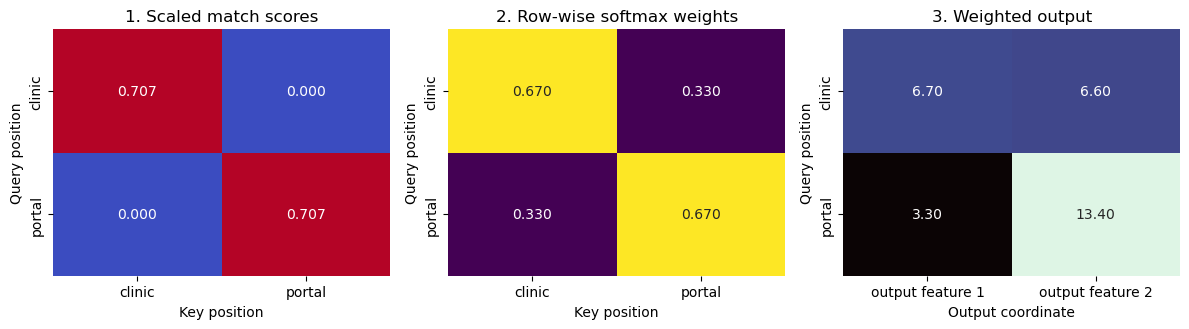

Weight row sums: [1.0, 1.0]


In [5]:
def scaled_dot_product_attention_from_scratch(query, key, value, allowed_mask=None):
    if query.shape[-1] != key.shape[-1]: raise ValueError('Query/key dimensions must match.')
    if key.shape[-2] != value.shape[-2]: raise ValueError('Key/value sequence lengths must match.')
    raw_scores = query @ key.transpose(-2,-1)
    scaled_scores = raw_scores / math.sqrt(query.shape[-1])
    if allowed_mask is not None:
        if torch.any(~allowed_mask.any(dim=-1)): raise ValueError('Every query row needs an allowed key.')
        scaled_scores = scaled_scores.masked_fill(~allowed_mask, -torch.inf)
    weights = torch.softmax(scaled_scores, dim=-1)
    return weights @ value, weights, scaled_scores, raw_scores

output, weights, scaled_scores, raw_scores = scaled_dot_product_attention_from_scratch(query,key,value)
expected_weights = torch.tensor([[.66976155,.33023845],[.33023845,.66976155]],dtype=DTYPE)
expected_output = torch.tensor([[6.69761549,6.60476902],[3.30238451,13.39523098]],dtype=DTYPE)
torch.testing.assert_close(weights,expected_weights,rtol=1e-6,atol=1e-7)
torch.testing.assert_close(output,expected_output,rtol=1e-6,atol=1e-7)

fig, axes = plt.subplots(1,3,figsize=(12,3.4))
for ax,data,title,cmap,fmt in zip(axes,[scaled_scores,weights,output],['1. Scaled match scores','2. Row-wise softmax weights','3. Weighted output'],['coolwarm','viridis','mako'],['.3f','.3f','.2f']):
    xlabels = labels if data.shape[1]==2 else ['feature 1','feature 2']
    if title.startswith('3.'): xlabels=['output feature 1','output feature 2']
    sns.heatmap(data.numpy(),annot=True,fmt=fmt,xticklabels=xlabels,yticklabels=labels,cmap=cmap,ax=ax,cbar=False)
    ax.set(title=title,ylabel='Query position',xlabel='Key position' if not title.startswith('3.') else 'Output coordinate')
plt.tight_layout(); plt.show()
print('Weight row sums:', weights.sum(-1).tolist())

### Read one row slowly

For query `clinic`, the scaled scores are `[0.707, 0.000]`. Row-wise softmax converts these to `[0.670, 0.330]`. The output is therefore:

`0.670 × [10, 0] + 0.330 × [0, 20] = [6.70, 6.60]`.

The second coordinate is larger than its weight because the second value contains `20`. **Weights and values both matter.** Attention weights alone do not show the final contribution.

## 5. Zoom in on softmax for one query

This paired chart separates scores from probabilities. Softmax is applied across one row—not down a column and not over the whole matrix. Scaling by `√2` makes the score gap less extreme than the raw dot products would be in a larger-dimensional example.

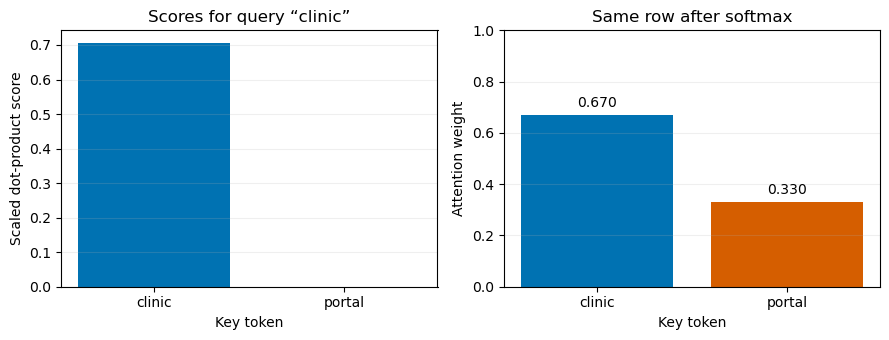

In [6]:
fig, axes = plt.subplots(1,2,figsize=(9,3.5),sharex=True)
axes[0].bar(labels, scaled_scores[0].numpy(), color=['#0072B2','#D55E00'])
axes[0].set(title='Scores for query “clinic”',ylabel='Scaled dot-product score',xlabel='Key token')
axes[1].bar(labels, weights[0].numpy(), color=['#0072B2','#D55E00'])
axes[1].set(title='Same row after softmax',ylabel='Attention weight',xlabel='Key token',ylim=(0,1))
for ax in axes: ax.grid(axis='y',alpha=.2)
for x,y in enumerate(weights[0]): axes[1].text(x,float(y)+.03,f'{float(y):.3f}',ha='center')
plt.tight_layout(); plt.show()

### Common misconception

Softmax does **not** choose the largest key and discard the rest. It creates a distribution. Sharper scores produce more concentrated weights; equal scores produce equal weights.

## 6. Apply a causal mask: before versus after

A **causal mask** prevents a position from using future positions. We replace disallowed scores with negative infinity *before* softmax, so their weights become exactly zero. The diagonal remains allowed, meaning a token can use itself.

The comparison below uses `True = allowed`. Other APIs sometimes use the opposite Boolean convention, so always check documentation.

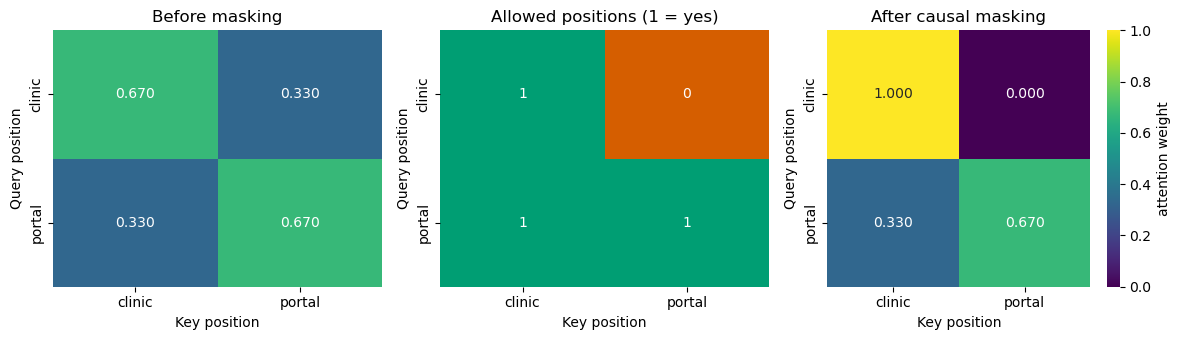

In [7]:
allowed_mask = torch.tril(torch.ones(2,2,dtype=torch.bool))
masked_output, masked_weights, masked_scores, _ = scaled_dot_product_attention_from_scratch(query,key,value,allowed_mask)
assert torch.allclose(masked_weights.sum(-1),torch.ones(2,dtype=DTYPE)) and masked_weights[0,1] == 0

fig, axes = plt.subplots(1,3,figsize=(12,3.5))
sns.heatmap(weights.numpy(),annot=True,fmt='.3f',xticklabels=labels,yticklabels=labels,cmap='viridis',vmin=0,vmax=1,ax=axes[0],cbar=False)
sns.heatmap(allowed_mask.numpy().astype(int),annot=True,fmt='d',xticklabels=labels,yticklabels=labels,cmap=['#D55E00','#009E73'],vmin=0,vmax=1,ax=axes[1],cbar=False)
sns.heatmap(masked_weights.numpy(),annot=True,fmt='.3f',xticklabels=labels,yticklabels=labels,cmap='viridis',vmin=0,vmax=1,ax=axes[2],cbar_kws={'label':'attention weight'})
for ax,title in zip(axes,['Before masking','Allowed positions (1 = yes)','After causal masking']):
    ax.set(title=title,xlabel='Key position',ylabel='Query position')
plt.tight_layout(); plt.show()

### What do we see?

The first query can use only its own key, so its row becomes `[1, 0]`. The second query can use both positions. Masking changes the available information; it does not merely hide a cell after computation.

**Learner check:** Can `clinic` use `portal` after masking? **No**—`portal` is later. Can `portal` use `clinic`? **Yes**—earlier positions are available.

## 7. Self-attention: Q, K, and V come from one sequence

In **self-attention**, one input matrix `X` is projected three ways: `Q=XW_Q`, `K=XW_K`, and `V=XW_V`. The projections allow “what I seek,” “how I can be matched,” and “what I contribute” to differ.

This fixed example has four tokens, three input features, and two projected features. It omits training, positional encodings, multiple heads, residual connections, normalization, and the feed-forward network found in a full Transformer.

In [8]:
tokens = ['clinic','schedules','followup','today']
X = torch.tensor([[1.,0.,0.],[0.,1.,0.],[1.,1.,0.],[0.,0.,1.]],dtype=DTYPE)
W_Q = torch.tensor([[1.,0.],[0.,1.],[.5,.5]],dtype=DTYPE)
W_K = W_Q.clone()
W_V = torch.tensor([[1.,0.],[0.,1.],[1.,1.]],dtype=DTYPE)
Q,K,V = X@W_Q, X@W_K, X@W_V
self_output,self_weights,_,_ = scaled_dot_product_attention_from_scratch(Q,K,V)
assert Q.shape==K.shape==V.shape==(4,2) and self_weights.shape==(4,4) and self_output.shape==(4,2)

display(pd.DataFrame({'object':['X','W_Q / W_K / W_V','Q / K / V','attention weights','output'],
                      'shape':['4 × 3','3 × 2','4 × 2','4 × 4','4 × 2'],
                      'meaning':['four token rows','learned in a real model','three views of X','every query-to-key pair','one contextualized row per token']}))

,object,shape,meaning
0,X,4 × 3,four token rows
1,W_Q / W_K / W_V,3 × 2,learned in a real model
2,Q / K / V,4 × 2,three views of X
3,attention weights,4 × 4,every query-to-key pair
4,output,4 × 2,one contextualized row per token


## 8. Visualize the self-attention weights and outputs

The left panel answers “which value rows contribute to each output row?” The right panel displays the resulting two-coordinate outputs. Read across a weight row; do not interpret the axes as clinical concepts.

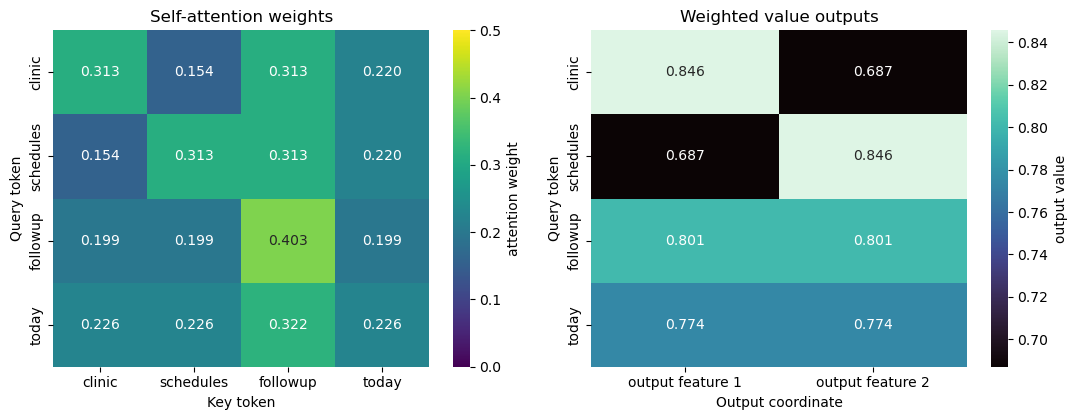

,clinic,schedules,followup,today
clinic,0.313,0.154,0.313,0.220
schedules,0.154,0.313,0.313,0.220
followup,0.199,0.199,0.403,0.199
today,0.226,0.226,0.322,0.226


In [9]:
fig, axes = plt.subplots(1,2,figsize=(11,4.3))
sns.heatmap(self_weights.numpy(),annot=True,fmt='.3f',xticklabels=tokens,yticklabels=tokens,cmap='viridis',vmin=0,vmax=.5,ax=axes[0],cbar_kws={'label':'attention weight'})
axes[0].set(title='Self-attention weights',xlabel='Key token',ylabel='Query token')
sns.heatmap(self_output.numpy(),annot=True,fmt='.3f',xticklabels=['output feature 1','output feature 2'],yticklabels=tokens,cmap='mako',ax=axes[1],cbar_kws={'label':'output value'})
axes[1].set(title='Weighted value outputs',xlabel='Output coordinate',ylabel='Query token')
plt.tight_layout(); plt.show()
display(pd.DataFrame(self_weights.numpy(),index=tokens,columns=tokens).round(3))

### What do we see?

For query `followup`, the largest computed weight is on key `followup` (`0.403`) in this fixture. The other keys still contribute. Because no positional encoding is included, this toy calculation knows only the supplied rows—not token order as a general concept.

**Self- versus cross-attention:** self-attention obtains Q/K/V from one sequence. Cross-attention obtains queries from one sequence and keys/values from another, such as decoder states querying encoder states.

## 9. Why attention alone cannot tell you the word order

Look back at the formula. `QKᵀ` compares every query with every key, and the softmax runs across a row. Nothing in that arithmetic refers to a token's **position**.

The consequence is concrete: if you shuffle the rows of `X`, self-attention produces the same output rows in the shuffled order. The content of each row does not change. Attention sees a *set* of tokens, not a sequence.

**Look for:** the maximum difference between the reordered output and the original output after undoing the shuffle. It should be zero.

In [10]:
order = [2, 0, 3, 1]                      # an arbitrary reordering of the four tokens
X_shuffled = X[order]
Q_s, K_s, V_s = X_shuffled @ W_Q, X_shuffled @ W_K, X_shuffled @ W_V
shuffled_output, _, _, _ = scaled_dot_product_attention_from_scratch(Q_s, K_s, V_s)

# Undo the shuffle so rows line up with the original token order again.
inverse = torch.argsort(torch.tensor(order))
recovered = shuffled_output[inverse]

print('original token order :', tokens)
print('shuffled token order :', [tokens[i] for i in order])
print()
display(pd.DataFrame(self_output.numpy(), index=tokens,
                     columns=['out 1', 'out 2']).round(4).rename_axis('original'))
display(pd.DataFrame(recovered.numpy(), index=tokens,
                     columns=['out 1', 'out 2']).round(4).rename_axis('shuffled then restored'))
print('maximum absolute difference:', float(torch.max(torch.abs(self_output - recovered))))

original token order : ['clinic', 'schedules', 'followup', 'today']
shuffled token order : ['followup', 'clinic', 'today', 'schedules']



,out 1,out 2
original,,
clinic,0.8457,0.6870
schedules,0.6870,0.8457
followup,0.8011,0.8011
today,0.7740,0.7740


,out 1,out 2
shuffled then restored,,
clinic,0.8457,0.6870
schedules,0.6870,0.8457
followup,0.8011,0.8011
today,0.7740,0.7740


maximum absolute difference: 0.0


### What do we see?

The difference is zero. Reordering the input reordered the output and changed nothing else.

For health text this matters directly. Consider two notes:

- *"result normal, not abnormal"*
- *"result abnormal, not normal"*

They contain the same tokens. Attention computed on token content alone cannot separate them. Word order carries the clinical meaning, and so far nothing in our calculation has represented it.

### Give each position its own signature

A **positional encoding** adds a position-dependent vector to each token's input row *before* the Q/K/V projections. Position 0 gets one pattern, position 1 a different one, and so on.

The original Transformer uses fixed sine and cosine waves at different frequencies:

`PE(pos, 2i) = sin(pos / 10000^(2i/d))` and `PE(pos, 2i+1) = cos(pos / 10000^(2i/d))`

The point is not the specific formula. The point is that every position receives a distinct, reproducible vector that is added to the token representation.

**Look for:** each row of the encoding is different, and the shuffle test now fails.

In [11]:
def sinusoidal_positional_encoding(n_positions, d_model, dtype=DTYPE):
    """Fixed sine/cosine position signatures, one row per sequence position."""
    position = torch.arange(n_positions, dtype=dtype).unsqueeze(1)
    index = torch.arange(d_model, dtype=dtype).unsqueeze(0)
    angle = position / torch.pow(10000.0, (2 * torch.div(index, 2, rounding_mode='floor')) / d_model)
    encoding = torch.where(index % 2 == 0, torch.sin(angle), torch.cos(angle))
    return encoding


X_positional = torch.tensor([[1., 0., 0., 0.], [0., 1., 0., 0.],
                             [1., 1., 0., 0.], [0., 0., 1., 0.]], dtype=DTYPE)
W = torch.tensor([[1., 0.], [0., 1.], [.5, .5], [.25, .75]], dtype=DTYPE)

position_encoding = sinusoidal_positional_encoding(4, 4)
display(pd.DataFrame(position_encoding.numpy(), index=[f'position {i}' for i in range(4)],
                     columns=[f'dim {j}' for j in range(4)]).round(4))

def self_attend(rows):
    Q, K, V = rows @ W, rows @ W, rows @ W
    output, weights, _, _ = scaled_dot_product_attention_from_scratch(Q, K, V)
    return output, weights

without_position, _ = self_attend(X_positional)
with_position, _ = self_attend(X_positional + position_encoding)

shuffled_with_position, _ = self_attend(X_positional[order] + position_encoding)
recovered_with_position = shuffled_with_position[inverse]

print('shuffle difference WITHOUT positional encoding:',
      float(torch.max(torch.abs(without_position - self_attend(X_positional[order])[0][inverse]))))
print('shuffle difference WITH    positional encoding:',
      float(torch.max(torch.abs(with_position - recovered_with_position))))

,dim 0,dim 1,dim 2,dim 3
position 0,0.0000,1.0000,0.00,1.0000
position 1,0.8415,0.5403,0.01,1.0000
position 2,0.9093,-0.4161,0.02,0.9998
position 3,0.1411,-0.9900,0.03,0.9996


shuffle difference WITHOUT positional encoding: 1.1102230246251565e-16
shuffle difference WITH    positional encoding: 0.8881179026384338


### What do we see?

Without positional encoding the shuffle difference is `1.1e-16` — zero to the limit of floating-point arithmetic. Order is invisible.

With positional encoding the difference is clearly non-zero. The same four tokens in a different order now produce genuinely different outputs, because each token arrived carrying a signature for where it sat in the sequence.

Two cautions:

- Positional encoding is added to the **input**, not to the attention formula. The `QKᵀ / √d_k → softmax → weights @ V` arithmetic is untouched.
- Modern models often use different schemes (learned embeddings, rotary encodings). The mechanism to remember is that position has to be injected somewhere, because attention itself is order-blind.

## 10. Compare with PyTorch's optimized function

[`torch.nn.functional.scaled_dot_product_attention`](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html) expects optional batch and head dimensions. We add them, disable dropout, run the official function, and remove them. Agreement checks our arithmetic—not model quality.

In [12]:
import torch.nn.functional as F
official = F.scaled_dot_product_attention(Q[None,None],K[None,None],V[None,None],dropout_p=0.0).squeeze(0).squeeze(0)
torch.testing.assert_close(self_output,official,rtol=1e-6,atol=1e-7)
comparison = pd.DataFrame({'custom':self_output.flatten().numpy(),'PyTorch':official.flatten().numpy(),'absolute difference':torch.abs(self_output-official).flatten().numpy()})
display(comparison.round(10))
print('Maximum absolute difference:',float(torch.max(torch.abs(self_output-official))))

,custom,PyTorch,absolute difference
0,0.845687,0.845687,0.0
1,0.687036,0.687036,0.0
2,0.687036,0.687036,0.0
3,0.845687,0.845687,0.0
4,0.801118,0.801118,0.0
5,0.801118,0.801118,0.0
6,0.773966,0.773966,0.0
7,0.773966,0.773966,0.0


Maximum absolute difference: 1.1102230246251565e-16


## 11. Try it yourself—predict before running

Choose one controlled change:

1. Replace the first query with `[0, 1]`. Which key should receive more weight?
2. Apply a 4×4 causal mask to `Q`, `K`, and `V`. How many allowed cells should each row contain? **Answer:** 1, 2, 3, and 4.
3. Double one row of `V`. Will the attention weights change? **No**—weights come from Q and K, but the output will change.

Keep all other values fixed so you can explain cause and effect.

## Summary and completion checklist

**Result:** attention first compares Q with K, normalizes each score row, and uses those weights to combine V. A mask changes which keys are available. Self-attention constructs Q/K/V from one sequence.

- [x] Traced shapes through `QKᵀ / √d_k → softmax → weights @ V`.
- [x] Verified every valid weight row sums to one.
- [x] Confirmed masked future positions receive zero weight.
- [x] Compared attention weights with output values.
- [x] Showed that attention alone is order-blind, and that positional encoding restores order.
- [x] Matched the explicit implementation to PyTorch.

**Limits:** one fixed head is not a trained Transformer. Attention weights are computed contributions, not causal explanations, clinical importance, or proof of understanding. Dense self-attention creates `n²` score entries. Next, retrieval selects external text before generation rather than assigning weights among tokens already in a sequence.